# Supervised Learning + Experiment Tracking

**Learning Objective** — Train multiple models with proper tracking discipline.

| Concept | What we cover |
|---|---|
| Model families | Linear models, decision trees, bagging, boosting, SVM |
| Cross-validation | Stratified K-Fold, CV score interpretation |
| Hyperparameter discipline | Config-driven params, no leakage into test set |
| Calibration | Reliability diagrams, when to calibrate |
| Inference bundle | `model.joblib` + `bundle_info.json` |

**Deliverables built here**
- Model leaderboard (ranked by ROC-AUC)
- Reproducible training commands (`python train.py --config …`)
- Inference bundle artifacts ready for serving

---

In [10]:
# ── Setup ────────────────────────────────────────────────────
import sys, pathlib
# Go up one level from notebooks/ to model-engineering/
ROOT = pathlib.Path(__file__).resolve().parent.parent if '__file__' in dir() else pathlib.Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.calibration import calibration_curve

from src.utils.common import load_yaml, set_seed
from src.features.preprocess import build_preprocessor
from src.models.trainer import train_model, build_model
from src.eval.metrics import classification_metrics

set_seed(42)
print('Ready.')


Ready.


## 1  Load the Titanic dataset

We use the preprocessed bake-off split from `data/processed/`.  
The feature set is the same across all models — changing only the *learner*.

> **Discipline rule:** the test split must never influence model selection or hyperparameter tuning.  
> Any model comparison must use cross-validation on the training split.

In [11]:
data_cfg   = load_yaml(ROOT / 'configs/data/titanic_bakeoff.yaml')
feature_cfg = load_yaml(ROOT / 'configs/features/titanic_all_features.yaml')

df = pd.read_csv(ROOT / data_cfg['dataset_path'])
target_col = data_cfg['target_column']
drop_cols  = feature_cfg.get('drop_columns', [])

X = df.drop(columns=[target_col] + drop_cols, errors='ignore')
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=float(data_cfg.get('test_size', 0.25)),
    random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}  Positive rate: {y.mean():.2%}')
X_train.head(3)

Train: (150, 7)  Test: (50, 7)  Positive rate: 49.00%


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
13,3,female,34.0,0,0,11.1363,S
21,1,male,20.0,1,0,72.1748,S
178,1,male,14.0,1,0,103.0710,S


## 2  Model families overview

We compare four families on identical features:

| Family | Learner | Inductive bias |
|---|---|---|
| **Linear** | `LogisticRegression` | Global decision boundary; very interpretable |
| **Tree** | `DecisionTreeClassifier` | Axis-aligned splits; prone to overfit |
| **Bagging** | `RandomForestClassifier` | Variance reduction via averaging many deep trees |
| **Boosting** | `GradientBoostingClassifier` | Bias reduction by learning residuals sequentially |
| **Kernel** | `SVC` | Max-margin in a kernel-induced feature space |

### Hyperparameter discipline
Every config lives in `configs/models/`.  
We **never touch test data** to pick hyperparam values — use CV mean on the train split only.

## 3  Train all models interactively

The cell below trains all five learners using the same
`train_model()` API that `train.py` uses — the configs drive everything.

In [12]:
CONFIGS = [
    ('logreg',    'configs/models/titanic_logreg.yaml'),
    ('dtree',     'configs/models/titanic_decision_tree.yaml'),
    ('rforest',   'configs/models/titanic_random_forest.yaml'),
    ('gboost',    'configs/models/titanic_gradient_boosting.yaml'),
    ('svm',       'configs/models/titanic_svm.yaml'),
]

results = {}  # name → {pipeline, metrics, cv_results}

for name, cfg_path in CONFIGS:
    model_cfg = load_yaml(ROOT / cfg_path)
    pipeline, cv_res = train_model(
        X_train=X_train, y_train=y_train,
        model_type=model_cfg['model_type'],
        model_params=model_cfg.get('params', {}),
        scale_numeric=feature_cfg.get('scale_numeric', True),
        calibrate=model_cfg.get('calibrate', False),
        cv_folds=5, cv_scoring='roc_auc',
    )
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    metrics = classification_metrics(y_test, y_pred, y_prob)
    results[name] = dict(pipeline=pipeline, metrics=metrics, cv=cv_res)
    cv_mean = cv_res.get('cv_roc_auc_mean', float('nan'))
    print(f'{name:10s}  test_roc_auc={metrics["roc_auc"]:.3f}  cv_roc_auc={cv_mean:.3f}')

logreg      test_roc_auc=0.792  cv_roc_auc=0.816
dtree       test_roc_auc=0.784  cv_roc_auc=0.808
rforest     test_roc_auc=0.817  cv_roc_auc=0.822
gboost      test_roc_auc=0.806  cv_roc_auc=0.772
svm         test_roc_auc=0.764  cv_roc_auc=0.840


## 4  Cross-validation deep dive

CV gives us an *unbiased estimate* of generalisation performance using only the
training split.  The variance across folds tells us how stable the learner is.

> High CV std → the estimator is sensitive to data perturbations (possible overfit or small dataset).

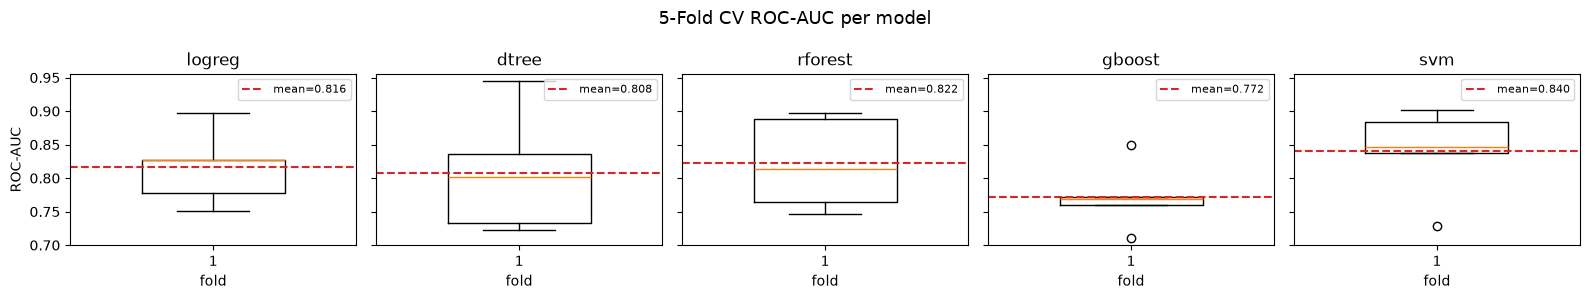

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(16, 3), sharey=True)
fig.suptitle('5-Fold CV ROC-AUC per model', fontsize=13)

for ax, (name, res) in zip(axes, results.items()):
    folds = res['cv'].get('cv_roc_auc_folds', [])
    mean  = res['cv'].get('cv_roc_auc_mean', float('nan'))
    ax.boxplot(folds, widths=0.5)
    ax.axhline(mean, color='tab:red', lw=1.5, ls='--', label=f'mean={mean:.3f}')
    ax.set_title(name)
    ax.set_xlabel('fold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8)

axes[0].set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

## 5  Model leaderboard

Leaderboard ranks all tracked experiments by test ROC-AUC.  
The CLI equivalent is:
```bash
python leaderboard.py
```

In [14]:
!pip install jinja2

rows = []
for name, res in results.items():
    m = res['metrics']
    cv = res['cv']
    rows.append({
        'model':          name,
        'accuracy':       round(m['accuracy'], 4),
        'precision':      round(m['precision'], 4),
        'recall':         round(m['recall'], 4),
        'f1':             round(m['f1'], 4),
        'test_roc_auc':   round(m['roc_auc'], 4),
        'cv_roc_auc_mean': round(cv.get('cv_roc_auc_mean', float('nan')), 4),
        'cv_roc_auc_std':  round(cv.get('cv_roc_auc_std',  float('nan')), 4),
    })

board = pd.DataFrame(rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
board.index += 1
board.index.name = 'rank'
board.style.background_gradient(subset=['test_roc_auc', 'cv_roc_auc_mean'], cmap='YlGn')


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


,model,accuracy,precision,recall,f1,test_roc_auc,cv_roc_auc_mean,cv_roc_auc_std
rank,,,,,,,,
1,rforest,0.760000,0.833300,0.625000,0.714300,0.817300,0.822100,0.062000
2,gboost,0.720000,0.727300,0.666700,0.695700,0.806100,0.772200,0.044200
3,logreg,0.740000,0.789500,0.625000,0.697700,0.791700,0.815900,0.050000
4,dtree,0.680000,0.642900,0.750000,0.692300,0.784500,0.807500,0.080300
5,svm,0.780000,0.842100,0.666700,0.744200,0.764400,0.839900,0.060400


### Reading the leaderboard

* **`test_roc_auc`** — single holdout evaluation; noisy on small datasets.
* **`cv_roc_auc_mean`** — more robust; prefer this for model selection.
* A big gap between `cv_roc_auc_mean` and `test_roc_auc` can signal **data leakage** or **test set drift** — investigate before shipping.

## 6  Calibration

A model is **calibrated** if the predicted probability matches the observed outcome rate.  
A reliability diagram (calibration curve) plots *mean predicted probability* vs *fraction positive*.

- A perfectly calibrated model follows the diagonal.
- **Decision trees / SVMs** tend to be poorly calibrated — wrap them with `CalibratedClassifierCV`.
- **Random forest** probabilities are already averaged over many trees — often reasonable out of the box.

In our configs `calibrate: true` adds an isotonic CalibratedClassifierCV wrapper for DT & SVM.

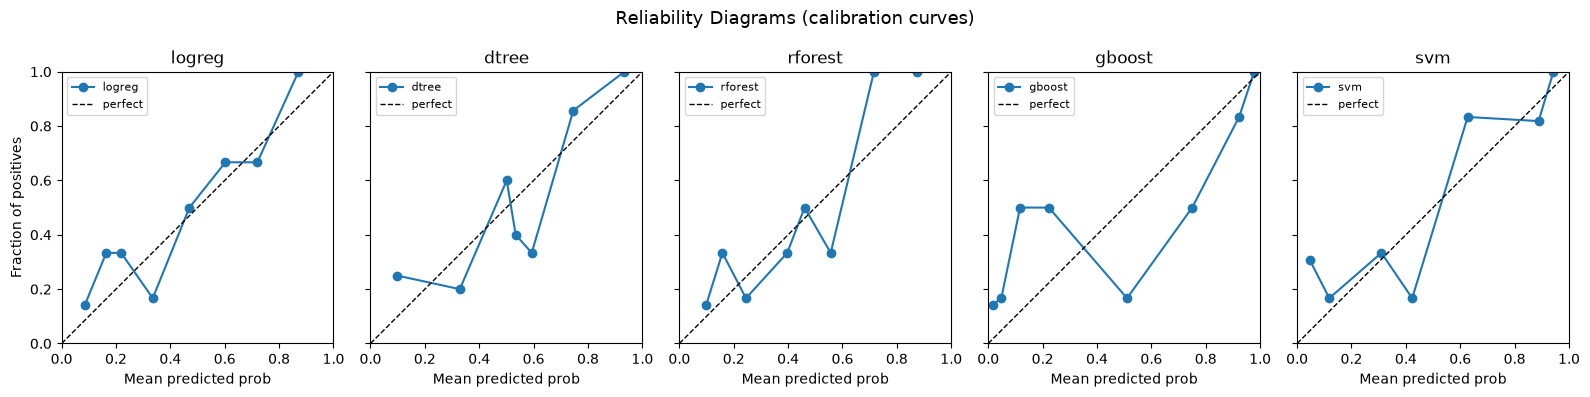

In [15]:
fig, axes = plt.subplots(1, len(results), figsize=(16, 4), sharey=True)
fig.suptitle('Reliability Diagrams (calibration curves)', fontsize=13)

for ax, (name, res) in zip(axes, results.items()):
    y_prob = res['pipeline'].predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=name)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect')
    ax.set_title(name)
    ax.set_xlabel('Mean predicted prob')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Fraction of positives')
plt.tight_layout()
plt.show()

## 7  Inference bundle

**Engineering rule:** offine training must produce an artifact ready for serving.

The CLI saves two files per run:
| File | Purpose |
|---|---|
| `model.joblib` | Fitted sklearn `Pipeline` (preprocessor → model) |
| `bundle_info.json` | Metadata: features expected, model type, trained-at timestamp |

The serving contract: **load the joblib, call `.predict()` / `.predict_proba()`** — no other preprocessing needed.

```bash
# Reproduce the best run from source config:
python train.py --config configs/train/titanic_random_forest.yaml
```

In [16]:
import joblib, json

# Use the random-forest run saved by the CLI
run_dir = ROOT / 'runs' / 'run_titanic_random_forest'

# ── Load bundle info ─────────────────────────────────────────
bundle_info = json.loads((run_dir / 'bundle_info.json').read_text())
print('Bundle info:')
for k, v in bundle_info.items():
    print(f'  {k}: {v}')

# ── Load model ───────────────────────────────────────────────
model = joblib.load(run_dir / 'model.joblib')

# ── Validate features match ──────────────────────────────────
expected = bundle_info['features']
assert list(X_test.columns) == expected, 'Feature mismatch — check preprocessing config!'

# ── Run inference ────────────────────────────────────────────
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

out = pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred, 'score': y_prob.round(3)})
print(f'\nInference on {len(out)} rows:')
out.head(10)

Bundle info:
  model_type: random_forest
  run_name: run_titanic_random_forest
  model_file: model.joblib
  features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
  calibrated: False
  trained_at: 2026-08-12T08:38:21.077172+00:00
  train_config: configs/train/titanic_random_forest.yaml

Inference on 50 rows:


,y_true,y_pred,score
0,1,1,0.917
1,1,1,0.759
2,1,1,0.838
3,0,0,0.330
4,0,0,0.138
5,0,0,0.085
6,0,0,0.255
7,1,0,0.457
8,0,0,0.132
9,1,1,0.947


## 8  Persistent leaderboard (file-backed)

Every `python train.py` call appends a row to `runs/summary.csv`.  
The leaderboard script reads that file so experiment history is never lost.

In [17]:
summary = pd.read_csv(ROOT / 'runs' / 'summary.csv')

# Show only the four new model-family runs
new_runs = summary[summary['run_name'].str.contains('decision_tree|random_forest|gradient_boosting|svm')].copy()
new_runs = new_runs.sort_values('roc_auc', ascending=False).reset_index(drop=True)
new_runs.index += 1
new_runs.index.name = 'rank'
cols = ['run_name', 'model', 'calibrated', 'accuracy', 'f1', 'roc_auc', 'cv_score_mean', 'cv_scoring']
new_runs[cols].round(4)

,run_name,model,calibrated,accuracy,f1,roc_auc,cv_score_mean,cv_scoring
rank,,,,,,,,
1,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
2,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
3,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
4,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
5,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
6,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
7,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
8,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc
9,run_titanic_random_forest,random_forest,False,0.76,0.7143,0.8173,0.8221,roc_auc


## 9  Reproducible training commands

Run each model from the command line — results go straight into `runs/summary.csv`:

```bash
# Logistic regression (baseline)
python train.py --config configs/train/titanic_all_features.yaml

# Decision tree (calibrated)
python train.py --config configs/train/titanic_decision_tree.yaml

# Random forest
python train.py --config configs/train/titanic_random_forest.yaml

# Gradient boosting
python train.py --config configs/train/titanic_gradient_boosting.yaml

# SVM (calibrated)
python train.py --config configs/train/titanic_svm.yaml

# View ranked leaderboard
python leaderboard.py
```

Each config pins *data path*, *feature set*, *model type*, *hyperparameters*, *CV settings*, and *seed* —  
the run is **fully reproducible** from a single `--config` argument.

---

### Key takeaways
1. Use **CV on the training split** for model selection — the test split is for final reporting only.
2. Check **calibration** before comparing probability-based metrics (ROC-AUC, log-loss).
3. The **inference bundle** (`model.joblib` + `bundle_info.json`) is the serving contract — validate feature lists on load.
4. Track every experiment row in `runs/summary.csv` so the leaderboard reflects full history.

In [18]:
!pip install pytz;
import datetime, pytz; 
print("Current Time in IST:", datetime.datetime.now(pytz.utc).astimezone(pytz.timezone('Asia/Kolkata')).strftime('%Y-%m-%d %H:%M:%S'))


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Current Time in IST: 2026-08-13 12:31:20
